# AI Research Agent — Colab project

In this notebook you build a research pipeline with three stages: a
**researcher** that gathers facts with web tools, an **analyst** that
interprets the findings, and a **writer** that produces the final report.
You build the agents yourself with LangChain's `create_agent`, and you
chain them into a workflow yourself with LangGraph's Graph API
(`StateGraph`). The tools, the tracing helpers, and the shared runner are
given to you — you only write the parts marked TODO. There are three
TODOs: write the prompts (TODO #1), build the three agents (TODO #2),
and build the pipeline (TODO #3).

**Google Colab (easiest):** open this notebook in Colab, add a secret
named `OPENROUTER_API_KEY` (the key icon in the left sidebar, or
`Runtime → Edit session secrets`), then run the cells top to bottom
(`Runtime → Run all`) after you finish the TODOs.

**On your own machine:** run `uv sync` in this folder, then
`uv run jupyter lab research_agent.ipynb`, and put your key in a `.env`
file (copy `.env.example`).

In [25]:
# On your own machine (not Colab) run: uv sync — and skip this cell
# !pip install -q "langchain>=1.4" "langgraph>=1.2.11" "langchain-openai>=1.2" beautifulsoup4 requests python-dotenv#


## 1. Setup

This cell is complete — just run it. It reads your API key (from Colab
Secrets, from `.env`, or by asking you) and creates `llm`, the model
object every agent in this notebook will use.

In [26]:
import getpass
import os
from typing import TypedDict

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

try:
    # Running in Google Colab? Read the key from Colab Secrets.
    from google.colab import userdata
    try:
        # userdata.get raises SecretNotFoundError if the secret is not set;
        # fall through to the getpass prompt below instead of erroring.
        api_key = userdata.get('OPENROUTER_API_KEY') or ''
    except Exception:
        api_key = ''
except ImportError:
    # Running locally? Read the key from a .env file.
    load_dotenv()
    api_key = os.environ.get('OPENROUTER_API_KEY', '')

if not api_key:
    # Last resort: ask for the key in this cell.
    api_key = getpass.getpass('Paste your OPENROUTER_API_KEY: ')
if not api_key:
    raise ValueError('Set OPENROUTER_API_KEY (Colab Secrets, .env, or paste it when asked)')

MODEL_NAME = 'liquid/lfm-2.5-2.6b:free'
llm = ChatOpenAI(model=MODEL_NAME, base_url='https://openrouter.ai/api/v1', api_key=api_key)

## 2. Observability helpers (given, run as-is)

Every agent run below prints a trace tree: one line per run, with the
token count and the real cost on it. Later you can swap this stub for real
Langfuse by changing one import — the function names match Langfuse's API.

In [27]:
# A small stand-in for Langfuse's @observe decorator.
# Swap to real Langfuse later by changing only the import, e.g.:
#     from langfuse import observe
import asyncio
import functools
import time
import uuid
from contextvars import ContextVar
from dataclasses import dataclass, field
from typing import Any, List, Optional


@dataclass
class Span:
    id: str
    name: str
    start_time: float
    level: int
    type: str = 'span'
    parent: Optional['Span'] = None
    children: List['Span'] = field(default_factory=list)
    end_time: Optional[float] = None
    input: Any = None
    output: Any = None
    metadata: dict = field(default_factory=dict)
    usage: dict = field(default_factory=dict)
    model: Optional[str] = None


_current_span: ContextVar[Optional[Span]] = ContextVar('current_span', default=None)


def print_tree(span: 'Span'):
    """Print one span and all of its children, indented by depth."""
    duration = (span.end_time - span.start_time) * 1000
    indent = '  ' * span.level
    prefix, suffix = ('=== TRACE: ', ' ===') if span.level == 0 else ('|-- ', '')
    meta_parts = []
    if span.model:
        meta_parts.append(f'model={span.model}')
    if span.usage.get('total_tokens'):
        meta_parts.append(f"tokens={span.usage['total_tokens']}")
    if 'cost_usd' in span.metadata:
        meta_parts.append(f"${span.metadata['cost_usd']:.4f}")
    meta_str = f" [{', '.join(meta_parts)}]" if meta_parts else ''
    type_str = f" [{span.type}]" if span.type != 'span' else ''
    print(f'{indent}{prefix}{span.name}{type_str}{suffix} ({duration:.2f}ms){meta_str}')
    for child in span.children:
        print_tree(child)


def _make_span(span_name: str, span_type: str, args, kwargs) -> 'Span':
    parent = _current_span.get()
    level = parent.level + 1 if parent else 0
    span = Span(id=str(uuid.uuid4())[:8], name=span_name, type=span_type,
                start_time=time.time(), level=level, parent=parent,
                input={'args': args, 'kwargs': kwargs})
    if parent:
        parent.children.append(span)
    return span


def _finish_span(span: 'Span'):
    span.end_time = time.time()
    if span.level == 0:
        print('\n' + '-' * 60)
        print_tree(span)
        print('-' * 60 + '\n')


def observe(name=None, as_type=None):
    """Decorator that records a span around a sync or async function."""
    def decorator(func):
        span_name = name if isinstance(name, str) else func.__name__
        span_type = as_type or 'span'

        if asyncio.iscoroutinefunction(func):
            @functools.wraps(func)
            async def wrapper(*args, **kwargs):
                span = _make_span(span_name, span_type, args, kwargs)
                token = _current_span.set(span)
                try:
                    result = await func(*args, **kwargs)
                    if span.output is None:
                        span.output = result
                    return result
                except Exception as e:
                    span.output = f'Error: {e}'
                    raise
                finally:
                    _finish_span(span)
                    _current_span.reset(token)
        else:
            @functools.wraps(func)
            def wrapper(*args, **kwargs):
                span = _make_span(span_name, span_type, args, kwargs)
                token = _current_span.set(span)
                try:
                    result = func(*args, **kwargs)
                    if span.output is None:
                        span.output = result
                    return result
                except Exception as e:
                    span.output = f'Error: {e}'
                    raise
                finally:
                    _finish_span(span)
                    _current_span.reset(token)

        return wrapper

    # Support both @observe and @observe(name='foo', as_type='bar')
    if callable(name):
        func, name = name, None
        return decorator(func)
    return decorator


class LangfuseContext:
    """Attach usage/model/cost data to the span currently being recorded."""

    def update_current_observation(self, **kwargs):
        span = _current_span.get()
        if not span:
            return
        if isinstance(kwargs.get('usage'), dict):
            span.usage.update(kwargs['usage'])
        if 'model' in kwargs:
            span.model = kwargs['model']
        if isinstance(kwargs.get('metadata'), dict):
            span.metadata.update(kwargs['metadata'])


langfuse_context = LangfuseContext()

In [28]:
# LoopDetector: spots when an agent repeats itself.
# check_tool_call flags repeated tool calls; check_output_stagnation flags
# stage outputs that keep coming back nearly identical.
from dataclasses import dataclass


@dataclass
class LoopDetectionResult:
    is_looping: bool
    strategy: str  # 'exact', 'fuzzy', 'stagnation', or 'none'
    message: str
    confidence: float


class LoopDetector:
    """Detects agent loops using exact match, fuzzy match, and stagnation."""

    def __init__(self, exact_threshold: int = 2, fuzzy_threshold: float = 0.8,
                 stagnation_window: int = 3):
        self.exact_threshold = exact_threshold
        self.fuzzy_threshold = fuzzy_threshold
        self.stagnation_window = stagnation_window
        self.tool_history: list[tuple[str, str]] = []  # (tool_name, args_str)
        self.output_history: list[str] = []

    def _jaccard_similarity(self, s1: str, s2: str) -> float:
        """Word-level overlap between two strings: shared words / all words."""
        tokens1 = set(s1.lower().split())
        tokens2 = set(s2.lower().split())
        if not tokens1 and not tokens2:
            return 1.0
        if not tokens1 or not tokens2:
            return 0.0
        return len(tokens1 & tokens2) / len(tokens1 | tokens2)

    def check_tool_call(self, tool_name: str, tool_input: str) -> LoopDetectionResult:
        """Call this BEFORE running a tool. Flags identical or near-identical repeats."""
        current = (tool_name, tool_input.strip())
        exact_count = sum(1 for past_tool, past_input in self.tool_history
                          if (past_tool, past_input.strip()) == current)
        if exact_count >= self.exact_threshold:
            self.tool_history.append(current)
            return LoopDetectionResult(
                is_looping=True, strategy='exact', confidence=1.0,
                message=(f"Exact loop detected: '{tool_name}' called {exact_count + 1} "
                         f'times with identical arguments. Change your approach.'))

        recent_history = self.tool_history[-5:]
        fuzzy_matches = sum(1 for past_tool, past_input in recent_history
                            if past_tool == tool_name
                            and self._jaccard_similarity(tool_input, past_input) >= self.fuzzy_threshold)
        if fuzzy_matches >= self.exact_threshold:
            self.tool_history.append(current)
            return LoopDetectionResult(
                is_looping=True, strategy='fuzzy', confidence=0.85,
                message=(f"Fuzzy loop detected: '{tool_name}' called with very similar "
                         f'arguments {fuzzy_matches + 1} times. Try a different approach.'))

        self.tool_history.append(current)
        return LoopDetectionResult(is_looping=False, strategy='none', message='', confidence=0.0)

    def check_output_stagnation(self, output: str) -> LoopDetectionResult:
        """Flags when the last few outputs are all nearly the same text."""
        self.output_history.append(output)
        if len(self.output_history) < self.stagnation_window:
            return LoopDetectionResult(is_looping=False, strategy='none', message='', confidence=0.0)

        recent = self.output_history[-self.stagnation_window:]
        similarities = [self._jaccard_similarity(recent[i], recent[j])
                        for i in range(len(recent)) for j in range(i + 1, len(recent))]
        avg_similarity = sum(similarities) / len(similarities) if similarities else 0
        if avg_similarity >= self.fuzzy_threshold:
            return LoopDetectionResult(
                is_looping=True, strategy='stagnation', confidence=avg_similarity,
                message=(f'Output stagnation detected: last {self.stagnation_window} '
                         f'outputs are {avg_similarity:.0%} similar. The agent is not '
                         f'making progress. Try a different approach entirely.'))
        return LoopDetectionResult(is_looping=False, strategy='none', message='', confidence=0.0)

    def reset(self):
        self.tool_history.clear()
        self.output_history.clear()

## 3. Research tools (given)

The `@tool` decorator turns a plain Python function into a tool the agent
can call. The function's name, docstring, and type hints become the schema
the model sees, and the returned string becomes the tool's result. This
cell is complete — run it.

In [29]:
import logging
import socket
from urllib.parse import urlparse

import requests
from bs4 import BeautifulSoup

logger = logging.getLogger(__name__)


def validate_url(url: str) -> bool:
    """
    Validate URL to prevent SSRF (Server-Side Request Forgery).
    Blocks localhost, private IP ranges, and non-http/https schemes.
    """
    try:
        parsed = urlparse(url)
        if parsed.scheme not in ["http", "https"]:
            return False

        hostname = parsed.hostname
        if not hostname:
            return False

        # Resolve hostname to IP
        try:
            ip_address = socket.gethostbyname(hostname)
        except socket.gaierror:
            return False # Could not resolve

        # Simple check for private ranges (10.x.x.x, 192.168.x.x, 172.16.x.x, 127.x.x.x)
        # In a real prod env, use the `ipaddress` module for strict checking
        parts = ip_address.split('.')
        if parts[0] == '10': return False
        if parts[0] == '192' and parts[1] == '168': return False
        if parts[0] == '172' and 16 <= int(parts[1]) <= 31: return False
        if parts[0] == '127': return False
        if ip_address == "0.0.0.0": return False

        return True
    except Exception:
        return False


@tool("search_web")
def search_web(query: str, max_results: int = 5) -> str:
    """Search the web for a query. Returns a list of results with title, link, and snippet."""
    url = "https://html.duckduckgo.com/html/"
    headers = {"User-Agent": "Mozilla/5.0"}

    try:
        response = requests.post(url, data={"q": query}, headers=headers, timeout=10)
        response.raise_for_status()
    except Exception as e:
        logger.error(f"Search request failed: {e}")
        # Return an error string gracefully instead of crashing the agent
        return f"Search failed: {e}"

    logger.info(f"Searching web for: '{query}'")

    soup = BeautifulSoup(response.text, "html.parser")
    lines = []
    for result in soup.find_all("div", class_="result", limit=max_results):
        title_tag = result.find("a", class_="result__a")
        snippet_tag = result.find("a", class_="result__snippet")

        if title_tag and snippet_tag:
            link = title_tag["href"]
            # Basic validation on the result link too
            if validate_url(link):
                lines.append(
                    f"{len(lines) + 1}. {title_tag.get_text(strip=True)}\n"
                    f"   Link: {link}\n"
                    f"   Snippet: {snippet_tag.get_text(strip=True)}"
                )

    logger.info(f"Search returned {len(lines)} results for '{query}'")
    if not lines:
        logger.warning(f"No results found for '{query}' (Raw response length: {len(response.text)})")
        return f"No results found for '{query}'."

    return "\n\n".join(lines)


@tool("read_webpage")
def read_webpage(url: str) -> str:
    """Read the content of a webpage. Returns the text content."""
    if not validate_url(url):
        return "Error: Invalid or restricted URL. Access to local/private networks is blocked."

    try:
        if "example.com" in url:
             return f"Simulated content for {url}."

        logger.info(f"Reading webpage: {url}")
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        # Remove script and style elements
        for script in soup(["script", "style"]):
            script.decompose()

        text = soup.get_text(separator="\n")
        # Clean up whitespace
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        text = '\n'.join(chunk for chunk in chunks if chunk)

        content = text[:10000]  # Truncate to avoid context overflow
        logger.info(f"Read {len(content)} chars from {url}")
        return content

    except Exception as e:
        return f"Error reading {url}: {e}"


# The tool list the researcher agent gets.
RESEARCH_TOOLS = [search_web, read_webpage]

In [30]:
# Quick smoke test that the tool works. Needs internet.
# If your network blocks DuckDuckGo, this prints an error string — that is fine.
print(search_web.invoke({'query': 'what is langgraph'}))

1. What is LangGraph - GeeksforGeeks
   Link: https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/
   Snippet: LangGraphisan open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control.

2. LangGraph: Agent Orchestration Framework for Reliable AI Agents - LangChain
   Link: https://www.langchain.com/langgraph
   Snippet: Control agent workflows withLangGraph: durable execution, memory, streaming, and human-in-the-loop.

3. What is LangGraph? - IBM
   Link: https://www.ibm.com/think/topics/langgraph
   Snippet: LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalab

## 4. The shared runner (given)

`run_agent` is the one function that calls any agent you build. It invokes
a compiled agent, pulls the final answer off the message list, adds up the
token usage, and records usage and the real cost from OpenRouter on the trace. It returns:

```python
{'answer': <final text>, 'metadata': {'total_messages': n, 'total_tokens': n}}
```

You will call `run_agent` from the pipeline nodes you write in TODO #3.

In [31]:
# @observe(name='agent_run', as_type='agent')
# async def run_agent(agent, query: str, max_steps: int = 10) -> dict:
#     result = await agent.ainvoke(
#         {'messages': [('user', query)]},
#         config={'recursion_limit': 2 * max_steps + 1},
#     )
#     messages = result['messages']
#     answer = messages[-1].content
#     total_tokens = sum((m.usage_metadata or {}).get('total_tokens', 0) for m in messages if getattr(m, 'usage_metadata', None))
#     langfuse_context.update_current_observation(usage={'total_tokens': total_tokens}, model=MODEL_NAME)
#     # Real cost in USD: OpenRouter returns it in each response's usage object.
#     total_cost = sum((m.response_metadata or {}).get('token_usage', {}).get('cost') or 0.0 for m in messages)
#     langfuse_context.update_current_observation(metadata={'cost_usd': round(total_cost, 6)})
#     return {'answer': answer, 'metadata': {'total_messages': len(messages), 'total_tokens': total_tokens}}

## 5. TODO #1 — prompts

Each agent's behavior comes from its system prompt:

- **Researcher**: gathers raw facts. It should call the web tools, collect
  relevant information, and report its findings with the links it used.
- **Analyst**: reads the research notes. It should find patterns, compare
  the points, and write a short structured analysis. It has no tools.
- **Writer**: reads the analysis. It should turn it into a clear final
  report for a beginner reader, with headings and a conclusion.

In [32]:
# # TODO #1: write a system prompt for the researcher.
# # Tell it to use the search_web and read_webpage tools and report findings with links.
# RESEARCHER_PROMPT = (
#     'You are a Research Specialist. Use search_web and read_webpage to gather '
#     'facts on the topic, and report them as a list with the source link next to '
#     'each one. If a tool fails or finds nothing, say so instead of guessing.'
# )

# # TODO #1: write a system prompt for the analyst.
# # Tell it to read the research notes and write a short structured analysis (no tools).
# ANALYST_PROMPT = (
#     'You are an Analysis Specialist. Read the research notes you are given and '
#     'write a short structured analysis: the key patterns, any contradictions, '
#     'and how confident you are. You have no tools — work only from the notes.'
# )

# # TODO #1: write a system prompt for the writer.
# # Tell it to turn the analysis into a clear final report for a beginner reader.
# WRITER_PROMPT = (
#     'You are a Writing Specialist. Turn the analysis you are given into a clear '
#     'final report for a beginner reader, with headings and a short conclusion.'
# )

## 6. TODO #2 — build the three agents

`create_agent` gives you the complete agent loop: a model node, a tools
node, and the routing between them. You do NOT write the loop yourself —
the model decides when to call a tool and when to answer.
`ToolCallLimitMiddleware` is the step budget: it stops the agent after a
fixed number of tool calls.

Here are the exact shapes to build (the analyst and writer have no tools,
so they need no middleware):

```python
researcher = create_agent(
    model=llm,
    tools=RESEARCH_TOOLS,
    system_prompt=RESEARCHER_PROMPT,
    middleware=[ToolCallLimitMiddleware(thread_limit=10, exit_behavior='end')],
)
analyst = create_agent(model=llm, tools=[], system_prompt=ANALYST_PROMPT)
writer = create_agent(model=llm, tools=[], system_prompt=WRITER_PROMPT)
```

In [33]:
# # TODO #2: replace each None with your create_agent call (pattern above).
# researcher = create_agent(
#     model=llm,
#     tools=RESEARCH_TOOLS,
#     system_prompt=RESEARCHER_PROMPT,
#     middleware=[ToolCallLimitMiddleware(thread_limit=10, exit_behavior='end')],
# )
# analyst = create_agent(model=llm, tools=[], system_prompt=ANALYST_PROMPT)
# writer = create_agent(model=llm, tools=[], system_prompt=WRITER_PROMPT)

## 7. TODO #3 — build the pipeline with the Graph API

`create_agent` builds ONE agent. To chain several agents into a workflow,
use LangGraph's Graph API: `StateGraph`. You define a shared state (a
`TypedDict`), one node function per stage, and the edges that say what
runs after what. The pipeline is: researcher → analyst → writer.

Here is the recipe:

```python
class PipelineState(TypedDict):
    query: str    # the original question
    report: str   # the text passed from stage to stage

async def researcher_node(state: PipelineState) -> dict:
    result = await run_agent(researcher, state['query'], 10)
    return {'report': result['answer']}

async def analyst_node(state: PipelineState) -> dict:
    result = await run_agent(analyst, state['report'], 10)
    return {'report': result['answer']}

async def writer_node(state: PipelineState) -> dict:
    result = await run_agent(writer, state['report'], 10)
    return {'report': result['answer']}

graph = StateGraph(PipelineState)
graph.add_node('researcher', researcher_node)
graph.add_node('analyst', analyst_node)
graph.add_node('writer', writer_node)
graph.add_edge(START, 'researcher')
graph.add_edge('researcher', 'analyst')
graph.add_edge('analyst', 'writer')
graph.add_edge('writer', END)
pipeline = graph.compile()

result = await pipeline.ainvoke({'query': query, 'report': ''})
```

Each node returns a dict of state updates; LangGraph merges them into the
shared state before the next node runs.

**The sequential pipeline above is a starting point — it cannot pass on
its own.** A straight line caps your architecture grade below the
passing threshold (see EVALUATION.md). To pass, change the graph: run
stages in parallel, send the writer's draft back to the researcher when
the fact-checker is not satisfied, or add a planner node that splits the
query first.

In [34]:
# class PipelineState(TypedDict):
#     query: str    # the original question
#     report: str   # the text passed from stage to stage

# async def researcher_node(state: PipelineState) -> dict:
#     result = await run_agent(researcher, state['query'], 10)
#     return {'report': result['answer']}

# async def analyst_node(state: PipelineState) -> dict:
#     result = await run_agent(analyst, state['report'], 10)
#     return {'report': result['answer']}

# async def writer_node(state: PipelineState) -> dict:
#     result = await run_agent(writer, state['report'], 10)
#     return {'report': result['answer']}

# graph = StateGraph(PipelineState)
# graph.add_node('researcher', researcher_node)
# graph.add_node('analyst', analyst_node)
# graph.add_node('writer', writer_node)
# graph.add_edge(START, 'researcher')
# graph.add_edge('researcher', 'analyst')
# graph.add_edge('analyst', 'writer')
# graph.add_edge('writer', END)
# pipeline = graph.compile()

# async def run_pipeline(query: str) -> dict:
#     assert researcher is not None and analyst is not None and writer is not None, 'finish TODO #2 first'
#     result = await pipeline.ainvoke({'query': query, 'report': ''})
#     return {'answer': result['report'], 'metadata': {'stages': 3}}

In [35]:
# Live run — this calls the model and the web tools three times, so it takes a minute.
# pipeline_result = await run_pipeline('Compare RAG and fine-tuning')
# print(pipeline_result['answer'])
# print(pipeline_result['metadata'])

## 8. Check your run

Every run above printed a trace tree: one span per agent run, with the
token count and the real cost on it. This cell prints the pipeline metadata.

In [36]:
# if 'pipeline_result' not in globals():
#     print('Finish TODO #2 and TODO #3 first, then run the pipeline cell.')
# else:
#     print('Pipeline metadata:', pipeline_result['metadata'])
#     print('The trace trees above show the tokens and real cost for each stage.')

## 9. Challenges (these earn the Observability points)

Two optional upgrades. Uncomment the code, adapt it, and run it.

- **Stagnation detection**: `LoopDetector.check_output_stagnation` flags
  when stage outputs keep coming back nearly identical — a sign the
  pipeline is going in circles. `check_tool_call` flags repeated tool calls.
- **Memory**: pass a checkpointer to `create_agent` and a `thread_id` in
  the config, and the agent remembers earlier turns in that thread.

For Architecture points, redesign the pipeline graph itself — see EVALUATION.md.

In [37]:
# # Challenge A — stagnation + repetition detection.
# # Run the three stages, keep each stage's answer, and compare them:
# # (collect each node result's answer in your pipeline, e.g. store stage answers in a dict as they run)
# #
# # detector = LoopDetector()
# # for stage_answer in [research_answer, analyst_answer, writer_answer]:
# #     check = detector.check_output_stagnation(stage_answer)
# #     if check.is_looping:
# #         print('Loop warning:', check.message)
# # Repetition: LoopDetector.check_tool_call('search_web', query)
# # returns is_looping=True when the same tool call repeats too often.
#
# # Challenge B — memory. An agent with a checkpointer remembers earlier turns.
# #
# # from langgraph.checkpoint.memory import InMemorySaver
# # memory_agent = create_agent(
# #     model=llm,
# #     tools=[],
# #     system_prompt='You are a helpful assistant.',
# #     checkpointer=InMemorySaver(),
# # )
# # config = {'configurable': {'thread_id': 'demo'}}
# # await memory_agent.ainvoke({'messages': [('user', 'My name is Sara.')]}, config=config)
# # reply = await memory_agent.ainvoke({'messages': [('user', 'What is my name?')]}, config=config)
# # print(reply['messages'][-1].content)

---
## My Solution

Everything below is added on top of the given TODOs — a planner, a critic
with a fact-check retry loop, and real cost/handoff caps.

## Prompts (all five, together)

`RESEARCHER_PROMPT`/`ANALYST_PROMPT`/`WRITER_PROMPT` are duplicates here for
reading — the real, graded copies live in TODO #1 above. `PLANNER_PROMPT`
and `REVIEW_PROMPT` are defined for real in this cell; the planner and
critic agents below use these directly.

In [38]:
RESEARCHER_PROMPT = (
    'You are a Research Specialist. You have two tools: search_web (the open '
    'web) and rag_search_courses (a local document — the official KFUPM ACCT '
    'course catalog). If the question is about a specific ACCT course at '
    'KFUPM (its description, credit hours, or prerequisites), use '
    'rag_search_courses first — it has the authoritative data search_web '
    'will not find. For anything else, use search_web. Report findings as a '
    'list with the source (link, or "KFUPM ACCT catalog") next to each one. '
    'If a tool fails or finds nothing, say so instead of guessing.'
)


ANALYST_PROMPT = (
    'You are an Analysis Specialist. Read the research notes you are given and '
    'write a short structured analysis: the key patterns, any contradictions, '
    'and how confident you are. You have no tools — work only from the notes.'
)

WRITER_PROMPT = (
    'You are a Writing Specialist. Turn the analysis you are given into a clear '
    'final report for a beginner reader, with headings and a short conclusion.'
)

PLANNER_PROMPT = (
    'You are a task planner for a research agent. Specialists: researcher '
    '(finds facts), analyst (evaluates), writer (synthesizes a report). '
    'Decompose the query into minimal ordered steps — researcher steps can '
    'run independently of each other.'
)

REVIEW_PROMPT = (
    'You are a fact-checking critic. Compare the report against the research '
    'findings. Approve only if every claim in the report is grounded in the '
    'findings. If not, explain specifically what is unsupported or wrong.'
)

## RAG tool (bonus — retrieval over a local document)

`courses.md` is the KFUPM ACCT course catalog, chunked one course per
section. `rag_search_courses` is a local keyword-retrieval tool (simple
TF-IDF-style scoring, pure Python — no embeddings API, so no external
network flakiness) that the researcher can call instead of `search_web`
for questions about specific ACCT courses.

In [39]:
import re
import math
from collections import Counter


def _load_course_chunks(path='courses.md'):
    text = open(path).read()
    parts = text.split('\n## ')
    chunks = []
    for i, part in enumerate(parts):
        if i == 0:
            continue  # the "# ACCT Course Catalog" title line, not a course
        body = '## ' + part
        header = body.split('\n', 1)[0].lstrip('# ').strip()
        chunks.append({'id': header, 'text': body})
    return chunks


COURSE_CHUNKS = _load_course_chunks()


def _tokenize(text: str) -> list[str]:
    return re.findall(r'[a-z0-9]+', text.lower())


# Document frequency across the whole catalog, for simple TF-IDF scoring.
_DOC_FREQ = Counter()
for _c in COURSE_CHUNKS:
    for _term in set(_tokenize(_c['text'])):
        _DOC_FREQ[_term] += 1
_N_DOCS = len(COURSE_CHUNKS)


def _score(query_terms: list[str], chunk_text: str) -> float:
    chunk_terms = Counter(_tokenize(chunk_text))
    score = 0.0
    for term in query_terms:
        if term in chunk_terms:
            idf = math.log((_N_DOCS + 1) / (_DOC_FREQ.get(term, 0) + 1)) + 1
            score += chunk_terms[term] * idf
    return score


@tool('rag_search_courses')
def rag_search_courses(query: str, top_k: int = 3) -> str:
    """Search the official KFUPM ACCT course catalog (a local document) for
    course descriptions, credit hours, and prerequisites. Use this instead
    of search_web when the question is about a specific ACCT course at
    KFUPM — search_web won't have this internal catalog data."""
    query_terms = _tokenize(query)
    if not query_terms:
        return 'No query terms provided.'
    scored = [(_score(query_terms, c['text']), c) for c in COURSE_CHUNKS]
    scored.sort(key=lambda x: x[0], reverse=True)
    top = [c for score, c in scored[:top_k] if score > 0]
    if not top:
        return f"No matching courses found in the catalog for '{query}'."
    return '\n\n---\n\n'.join(c['text'] for c in top)


print(f'RAG ready: {len(COURSE_CHUNKS)} course chunks loaded from courses.md')

RAG ready: 39 course chunks loaded from courses.md


## Agents 

### Planner

Decomposes the query into ordered steps, each assigned to a specialist.
Same `PlanStep`/`Plan` shape as the newsroom lab's planner, structured
output so the shape is guaranteed rather than hoped for.

### Critic

Checks the writer's final report against the researcher's findings and
returns a structured verdict — approved or not, with specific feedback.
Same structured-output pattern as the planner, so the verdict's shape is
guaranteed rather than parsed from free text.

In [40]:
from pydantic import BaseModel, Field

class PlanStep(BaseModel):
    step: int = Field(..., description='Step number')
    task: str = Field(..., description='Task to perform')
    specialist: str = Field(..., description='One of: researcher, analyst, writer')
    depends_on: list[int] = Field(default_factory=list)

class Plan(BaseModel):
    steps: list[PlanStep]
    
class ReviewVerdict(BaseModel):
    approved: bool = Field(..., description='True if every claim in the report is grounded in the findings.')
    feedback: str = Field(..., description='Specific revision notes when approved is False.')
    
researcher = create_agent(
    model=llm,
    tools=RESEARCH_TOOLS + [rag_search_courses],
    system_prompt=RESEARCHER_PROMPT,
    middleware=[ToolCallLimitMiddleware(run_limit=20, exit_behavior='end')],
)
analyst = create_agent(model=llm, tools=[], system_prompt=ANALYST_PROMPT)
writer = create_agent(model=llm, tools=[], system_prompt=WRITER_PROMPT)
critic = create_agent(model=llm, tools=[], system_prompt=REVIEW_PROMPT, response_format=ReviewVerdict)
planner = create_agent(model=llm, tools=[], system_prompt=PLANNER_PROMPT, response_format=Plan)

## State

The shared whiteboard every node reads and writes — the original query,
the planner's `plan`, the merged `findings` (one entry per concurrent
researcher step), the evolving `report`, and the caps (`revisions`,
`cost_usd`, `handoffs`) that keep the revise loop from running forever.
`findings`/`cost_usd`/`handoffs` use `operator.add` reducers so concurrent
researcher branches merge correctly instead of racing.

In [41]:
from typing import Annotated
import operator

class DeepSearchState(TypedDict):
    query: str        # the original question
    plan: list          # PlanSteps from the planner
    findings: Annotated[list[str], operator.add]  # one entry per researcher step, merged by the reducer
    report: str        # analyst's output, then writer's output
    report_history: Annotated[list[str], operator.add]  # every past report version, for stagnation detection
    feedback: str      # critic's notes when a revision is needed
    decision: str      # 'ship' | 'revise'
    revisions: int
    max_revisions: int
    cost_usd: Annotated[float, operator.add]    # each node returns only ITS OWN cost; the reducer sums them
    budget_usd: float
    handoffs: Annotated[int, operator.add]      # each node returns 1; the reducer sums them
    max_handoffs: int

## my_run_agent

Same job as the given `run_agent`, but returns the real per-call cost and
falls back to the structured response for the planner/critic. One function
instead of three near-duplicates.

In [42]:
# my_run_agent: like the given run_agent, but also returns cost_usd (needed to
# accumulate real cost into DeepSearchState) and falls back to
# result['structured_response'] when it's set — so this one function covers
# researcher/analyst/writer (plain text) AND planner/critic (structured output),
# replacing the separate run_planner/run_critic helpers.
#
# Takes `role` and builds the trace span manually (instead of @observe with a
# fixed name) so each trace line is labeled with which agent actually ran —
# @observe's name is fixed at decoration time, so every call would otherwise
# print the same generic label and you couldn't tell them apart.
async def my_run_agent(agent, role: str, query: str, max_steps: int = 10) -> dict:
    span = _make_span(role, 'agent', (agent, query), {'max_steps': max_steps})
    token = _current_span.set(span)
    try:
        result = await agent.ainvoke(
            {'messages': [('user', query)]},
            config={'recursion_limit': 2 * max_steps + 1},
        )
        messages = result['messages']
        total_tokens = sum((m.usage_metadata or {}).get('total_tokens', 0) for m in messages if getattr(m, 'usage_metadata', None))
        langfuse_context.update_current_observation(usage={'total_tokens': total_tokens}, model=MODEL_NAME)
        total_cost = sum((m.response_metadata or {}).get('token_usage', {}).get('cost') or 0.0 for m in messages)
        langfuse_context.update_current_observation(metadata={'cost_usd': round(total_cost, 6)})
        # Which tools actually got called — each executed tool call leaves a
        # ToolMessage with the tool's name on it. Makes it visible afterwards
        # which source (e.g. rag_search_courses vs search_web) was actually used.
        tools_used = [m.name for m in messages if m.__class__.__name__ == 'ToolMessage' and m.name]
        structured = result.get('structured_response')
        answer = structured if structured is not None else messages[-1].content
        span.output = answer
        return {'answer': answer, 'metadata': {'total_messages': len(messages), 'total_tokens': total_tokens,
                                                'cost_usd': round(total_cost, 6), 'tools_used': tools_used}}
    except Exception as e:
        span.output = f'Error: {e}'
        raise
    finally:
        _finish_span(span)
        _current_span.reset(token)

## The nodes

`plan_node` runs the planner once. `researcher_node` is Send-targeted — it
runs once per independent researcher step, concurrently, and only returns
its own cost/handoff delta since it never sees the full state. `analyst`,
`writer`, and `review` stay sequential; `analyst` reads the critic's
feedback on a revise pass, and `review` makes the ship-or-revise call while
checking every cap in one place.

In [43]:
async def plan_node(state: DeepSearchState) -> dict:
    result = await my_run_agent(planner, 'planner', state['query'])
    plan: Plan = result['answer']
    steps = [s.model_dump() for s in plan.steps]
    print('=== PLAN ===')
    for s in steps:
        print(f"  step {s['step']} [{s['specialist']}] depends_on={s['depends_on']}: {s['task']}")
    print()
    return {'plan': steps,
            'cost_usd': result['metadata']['cost_usd'],
            'handoffs': 1}

async def researcher_node(payload: dict) -> dict:
    # Send-targeted: receives just {'task': ...}, not the full state — so it
    # can't read/add to state['cost_usd'] like the sequential nodes below.
    # It returns only its own delta; the reducer sums concurrent branches.
    # TEMP: max_steps=25 -> recursion_limit=51, headroom above run_limit=20
    # (each tool call takes ~2 graph steps), so the ToolCallLimitMiddleware's
    # graceful exit_behavior='end' kicks in before LangGraph's own recursion
    # limit raises a hard GraphRecursionError. Revisit once we understand why
    # the researcher wants this many calls in the first place.
    print(f"=== RESEARCHER task: {payload['task']}")
    result = await my_run_agent(researcher, 'researcher', payload['task'], 25)
    preview = result['answer'][:300].replace('\n', ' ')
    tools_used = result['metadata']['tools_used']
    tools_str = ', '.join(tools_used) if tools_used else '(none)'
    print(f"=== RESEARCHER done ({result['metadata']['total_messages']} messages, "
          f"tools used: {tools_str}): {preview}...\n")
    return {'findings': [result['answer']],
            'cost_usd': result['metadata']['cost_usd'],
            'handoffs': 1}

async def analyst_node(state: DeepSearchState) -> dict:
    findings_text = '\n\n'.join(state['findings'])
    if state['feedback']:
        task = (f"Findings:\n{findings_text}\n\n"
                f"Your previous analysis led to a report that was rejected. "
                f"Feedback:\n{state['feedback']}\n\nRe-analyze with this feedback in mind.")
    else:
        task = findings_text
    result = await my_run_agent(analyst, 'analyst', task, 10)
    return {'report': result['answer'],
            'cost_usd': result['metadata']['cost_usd'],
            'handoffs': 1}

async def writer_node(state: DeepSearchState) -> dict:
    result = await my_run_agent(writer, 'writer', state['report'], 10)
    return {'report': result['answer'],
            'cost_usd': result['metadata']['cost_usd'],
            'handoffs': 1}

async def review_node(state: DeepSearchState) -> dict:
    findings_text = '\n\n'.join(state['findings'])
    task = f"Findings:\n{findings_text}\n\nReport:\n{state['report']}"
    result = await my_run_agent(critic, 'critic', task)
    verdict: ReviewVerdict = result['answer']
    cost_delta = result['metadata']['cost_usd']
    # cap-check against the PROJECTED total (state's running total, which
    # doesn't yet include this call's own delta, plus that delta) — but the
    # return still reports only the delta, so the reducer doesn't double-count.
    projected_cost = state['cost_usd'] + cost_delta
    projected_handoffs = state['handoffs'] + 1

    # LoopDetector: is this revision cycle actually converging, or just
    # spinning on near-identical text? Fresh detector each call (state
    # holds the data, not the stateful object), replay past + current
    # reports so the rolling stagnation_window still works correctly.
    detector = LoopDetector()
    stagnation = LoopDetectionResult(is_looping=False, strategy='none', message='', confidence=0.0)
    for past_report in state['report_history'] + [state['report']]:
        stagnation = detector.check_output_stagnation(past_report)
    if stagnation.is_looping:
        print(f'=== LOOP DETECTOR: {stagnation.message}\n')

    if verdict.approved:
        return {'decision': 'ship', 'feedback': '', 'cost_usd': cost_delta, 'handoffs': 1,
                'report_history': [state['report']]}

    capped = (state['revisions'] >= state['max_revisions']
              or projected_cost > state['budget_usd']
              or projected_handoffs >= state['max_handoffs']
              or stagnation.is_looping)
    if capped:
        # gave up rather than looped forever — ship the best report we have
        feedback = verdict.feedback
        if stagnation.is_looping:
            feedback = f'{feedback} [Stopped early — {stagnation.message}]'
        return {'decision': 'ship', 'feedback': feedback, 'cost_usd': cost_delta, 'handoffs': 1,
                'report_history': [state['report']]}

    return {'decision': 'revise', 'feedback': verdict.feedback,
            'revisions': state['revisions'] + 1, 'cost_usd': cost_delta, 'handoffs': 1,
            'report_history': [state['report']]}

## The graph

`plan → dispatch_research` fans out one `Send()` per independent researcher
step (concurrent), then the graph continues `researcher → analyst → writer
→ review`. A conditional edge sends review's verdict either to `END` or
back to `analyst` — two non-sequential patterns (parallel research +
retry loop) instead of one.

In [44]:
from langgraph.types import Send

def dispatch_research(state: DeepSearchState) -> list:
    """Router: one Send per researcher step in the plan — the planner's
    prompt only promises researcher steps can run independently, so only
    those get fanned out; analyst/writer/review stay sequential below."""
    tasks = [s['task'] for s in state['plan'] if s['specialist'] == 'researcher']
    if not tasks:
        tasks = [state['query']]  # fallback: plan had no researcher step
    return [Send('researcher', {'task': t}) for t in tasks]

def route_after_review(state: DeepSearchState) -> str:
    return 'ship' if state['decision'] == 'ship' else 'revise'

deep_search_graph = StateGraph(DeepSearchState)
deep_search_graph.add_node('plan', plan_node)
deep_search_graph.add_node('researcher', researcher_node)
deep_search_graph.add_node('analyst', analyst_node)
deep_search_graph.add_node('writer', writer_node)
deep_search_graph.add_node('review', review_node)

deep_search_graph.add_edge(START, 'plan')
deep_search_graph.add_conditional_edges('plan', dispatch_research, ['researcher'])
deep_search_graph.add_edge('researcher', 'analyst')
deep_search_graph.add_edge('analyst', 'writer')
deep_search_graph.add_edge('writer', 'review')
deep_search_graph.add_conditional_edges('review', route_after_review, {'ship': END, 'revise': 'analyst'})

deep_search_pipeline = deep_search_graph.compile()

## Render it

A quick sanity check — draws the compiled graph so the loop is visible,
not just described in prose.

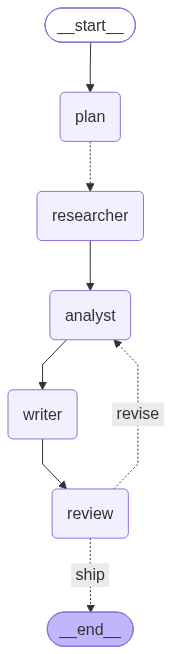

In [45]:
from IPython.display import Image, display
display(Image(deep_search_pipeline.get_graph().draw_mermaid_png()))

In [46]:
async def run_deepsearch(query: str) -> dict:
    assert researcher is not None and analyst is not None and writer is not None, 'finish TODO #2 first'
    result = await deep_search_pipeline.ainvoke({
        'query': query, 'plan': [], 'findings': [], 'report': '', 'report_history': [],
        'feedback': '', 'decision': '',
        'revisions': 0, 'max_revisions': 2,
        'cost_usd': 0.0, 'budget_usd': 0.05,
        'handoffs': 0, 'max_handoffs': 8,
    })
    return {'answer': result['report'],
            'metadata': {'revisions': result['revisions'], 'handoffs': result['handoffs'],
                         'cost_usd': result['cost_usd'], 'decision': result['decision'],
                         # debug: see what each stage actually produced
                         'plan': result['plan'], 'findings': result['findings']}}

In [47]:
# Live run of the custom deep-search pipeline — calls the model and web
# tools multiple times (more if it revises), so it can take a minute or two.
deepsearch_result = await run_deepsearch('Compare RAG and fine-tuning')
print(deepsearch_result['answer'])
print(deepsearch_result['metadata'])


------------------------------------------------------------
=== TRACE: planner [agent] === (4792.37ms) [model=liquid/lfm-2.5-2.6b:free, tokens=717, $0.0000]
------------------------------------------------------------

=== PLAN ===
  step 1 [researcher] depends_on=[]: Research RAG (Retrieval-Augmented Generation)
  step 2 [researcher] depends_on=[]: Research fine-tuning approach

=== RESEARCHER task: Research RAG (Retrieval-Augmented Generation)
=== RESEARCHER task: Research fine-tuning approach

------------------------------------------------------------
=== TRACE: researcher [agent] === (18928.03ms) [model=liquid/lfm-2.5-2.6b:free, tokens=8446, $0.0000]
------------------------------------------------------------

=== RESEARCHER done (7 messages, tools used: search_web, read_webpage, read_webpage): # Retrieval-Augmented Generation (RAG) – Research Summary  ## Overview  **Retrieval-Augmented Generation (RAG)** is a technique that enables large language models (LLMs) to retrieve and

In [ ]:
# RAG test: this should make the researcher use rag_search_courses (the
# local KFUPM ACCT catalog) instead of search_web.
kfupm_result = await run_deepsearch(
    "I am a new KFUPM student — could you list me the accounting courses there?"
)
print(kfupm_result['answer'])
print(kfupm_result['metadata'])


------------------------------------------------------------
=== TRACE: planner [agent] === (1276.04ms) [model=liquid/lfm-2.5-2.6b:free, tokens=347, $0.0000]
------------------------------------------------------------

=== PLAN ===
  step 1 [research] depends_on=[]: Search for KFUPM accounting courses

=== RESEARCHER task: I am a new KFUPM student — could you list me the accounting courses there?

------------------------------------------------------------
=== TRACE: researcher [agent] === (7847.70ms) [model=liquid/lfm-2.5-2.6b:free, tokens=4604, $0.0000]
------------------------------------------------------------

=== RESEARCHER done (4 messages, tools used: rag_search_courses): Here is a complete list of accounting courses offered by KFUPM (ACCT program) based on the official course catalog:  | Course Code | Course Name | Credit Hours (Lecture-Lab-Credit) | Pre-Requisites | |-------------|------------|----------------------------------|----------------| | **ACCT 110** | In...


-